In [1]:
!pip install torch pandas matplotlib
!pip install "protobuf>=4.25.3,<5.0.0" "tensorflow>=2.16.1"
!pip install -q unbabel-comet transformers --upgrade

import google.protobuf
import tensorflow as tf
print(f"Protobuf version: {google.protobuf.__version__}")
print(f"TensorFlow version: {tf.__version__}")

INFO: pip is looking at multiple versions of tensorflow to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 98.8 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.1 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorf

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from comet import download_model, load_from_checkpoint

In [3]:
# Try primary AfriCOMET checkpoint
try:
    model_path = download_model("masakhane/africomet")
    print("Loaded primary AfriCOMET checkpoint")

except:
    print("Primary checkpoint unavailable.")
    print("Trying fallback checkpoint...")

    model_path = download_model("masakhane/africomet-qe-stl")

# Load model
comet_model = load_from_checkpoint(model_path)

print("AfriCOMET model ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Primary checkpoint unavailable.
Trying fallback checkpoint...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

hparams.yaml:   0%|          | 0.00/573 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/714 [00:00<?, ?B/s]

AfriCOMET model ready.


In [4]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [6]:
corrected_preds = load_json("corrected_predictions.json")
retrained_preds = load_json("retrained_predictions.json")
rag_rat_preds = load_json("rat_predictions.json")
const_preds = load_json("constrained_predictions.json")
post_preds = load_json("post_processing_predictions.json")

sources = load_json("retrained_sources.json")

references = load_json("retrained_references.json")

In [7]:
# def extract_pred(x):
#     if isinstance(x, dict):
#         return x.get("prediction") or x.get("text") or ""
#     return x

def clean_pred(x):
    if isinstance(x, dict):
        x = x.get("prediction", "")
    if isinstance(x, str):
        return x.strip().strip('"')
    return str(x)

In [9]:
paired_data = []

# Calculate the minimum length to avoid IndexError if lists are mismatched
n = min(
    len(references),
    len(sources),
    len(corrected_preds),
    len(retrained_preds),
    len(rag_rat_preds),
    len(const_preds),
    len(post_preds)
)

for i in range(n):
    paired_data.append({
        "id": i,
        "source": sources[i],
        "reference": references[i],
        "corrected": clean_pred(corrected_preds[i]),
        "retrained": clean_pred(retrained_preds[i]),
        "rag_rat": clean_pred(rag_rat_preds[i]),
        "constrained": clean_pred(const_preds[i]),
        "post": clean_pred(post_preds[i]),
    })

print(f"Paired {len(paired_data)} examples.")

Paired 10 examples.


In [11]:
# Verify that our paired dataset contains the expected number of samples
assert len(paired_data) == n
print(f"Validation successful: Processing {n} paired samples.")

Validation successful: Processing 10 paired samples.


In [12]:
print(paired_data[0])

{'id': 0, 'source': '"We now have 4-month-old mice that are non-diabetic that used to be diabetic," he added.', 'reference': '"Manje sinamagundane anezinyanga ezingu-4 angenawo ushukela ayenoshukela," wanezela.', 'corrected': 'Manje sinezimbuzi ezinezinyanga ezine ubudala ezingenawo ushukela ezazikade zinoshukela", enezela.', 'retrained': 'Manje sinezindundane ezinenyanga ezine ubudala ezingenazifo sikashukela ezazisebenzisa isifo sikashukela," esho esho.', 'rag_rat': 'Manje sinamagundane aneminyaka engu-4 ubudala angenawo isifo sikashukela ebekade enesifo sikashukela," wanezela.', 'constrained': 'Sisenamagundane anenyanga ezine ubudala angenawo isifo sikashukela futhi abelokhu ene-sifo sikashukela," enezele. Unganyakazisa.', 'post': 'Manje sinezindundane ezinenyanga ezine ubudala ezingenazifo sikashukela ezazisebenzisa isifo sikashukela," enezela.'}


In [16]:
def comet_score(system_key, data, model):

    inputs = [
        {
            "src": ex["source"],
            "mt": ex[system_key],
            "ref": ex["reference"]
        }
        for ex in data
    ]

    output = model.predict(inputs, batch_size=8, gpus=0)

    return np.array(output.scores)

In [17]:
scores = {}

systems = ["corrected", "retrained", "rag_rat", "constrained", "post"]

for s in systems:
    print(f"Scoring {s}...")
    scores[s] = comet_score(s, paired_data, comet_model)

print("Scoring complete.")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Scoring corrected...


Predicting DataLoader 0: 100%|██████████| 2/2 [00:14<00:00,  7.41s/it]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Scoring retrained...


Predicting DataLoader 0: 100%|██████████| 2/2 [00:13<00:00,  6.88s/it]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Scoring constrained...


Predicting DataLoader 0: 100%|██████████| 2/2 [00:28<00:00, 14.50s/it]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Scoring post...


Predicting DataLoader 0: 100%|██████████| 2/2 [00:13<00:00,  6.97s/it]

Scoring complete.


In [18]:
for k, v in scores.items():
    print(k, np.mean(v))


corrected_scores  = scores["corrected"]
retrained_scores  = scores["retrained"]
rag_scores        = scores["rag_rat"]
post_scores       = scores["post"]



corrected 0.7360788226127625
retrained 0.698400354385376
rag_rat 0.7172411859035492
constrained 0.49444845542311666
post 0.7101663589477539


In [20]:
print("Corrected:", corrected_scores.mean())
print("Retrained:", retrained_scores.mean())
print("RAT:", rag_scores.mean())
print("Post-processed:", post_scores.mean())

Corrected: 0.7360788226127625
Retrained: 0.698400354385376
RAT: 0.7172411859035492
Post-processed: 0.7101663589477539


In [21]:
import numpy as np

def paired_bootstrap_multi(score_dict, n_bootstrap=5000, seed=42):

    np.random.seed(seed)

    systems = list(score_dict.keys())
    n = len(score_dict[systems[0]])

    results = {sys: [] for sys in systems}

    for _ in range(n_bootstrap):

        # SAME sampled indices for ALL systems (this preserves pairing)
        idx = np.random.randint(0, n, n)

        sample_means = {}

        for sys in systems:
            sample = score_dict[sys][idx]
            sample_means[sys] = np.mean(sample)

        for sys in systems:
            results[sys].append(sample_means[sys])

    # convert lists → arrays
    for sys in systems:
        results[sys] = np.array(results[sys])

    return results

In [22]:
score_dict = {
    "corrected": corrected_scores,
    "retrained": retrained_scores,
    "rag_rat": rag_scores,
    "post": post_scores
}
bootstrap_results = paired_bootstrap_multi(score_dict)

In [23]:
def summarize(name, values):
    return {
        "system": name,
        "mean": np.mean(values),
        "ci_lower": np.percentile(values, 2.5),
        "ci_upper": np.percentile(values, 97.5),
    }

In [24]:
summary_table = pd.DataFrame([
    summarize(k, v) for k, v in bootstrap_results.items()
])

summary_table = summary_table.sort_values("mean", ascending=False)

print(summary_table)

      system      mean  ci_lower  ci_upper
0  corrected  0.735984  0.678694  0.785405
2    rag_rat  0.716826  0.651600  0.775988
3       post  0.709797  0.654233  0.758869
1  retrained  0.697785  0.642498  0.749724


In [25]:
def bootstrap_diff(a, b, n_bootstrap=5000, seed=42):

    np.random.seed(seed)

    n = len(a)
    diffs = []

    for _ in range(n_bootstrap):
        idx = np.random.randint(0, n, n)

        diff = np.mean(b[idx]) - np.mean(a[idx])
        diffs.append(diff)

    diffs = np.array(diffs)

    return {
        "mean_diff": np.mean(diffs),
        "ci_lower": np.percentile(diffs, 2.5),
        "ci_upper": np.percentile(diffs, 97.5),
        "p_value": np.mean(diffs <= 0),
        "dist": diffs
    }

In [26]:
corrected_vs_retrained = bootstrap_diff(corrected_scores, retrained_scores)

corrected_vs_rag = bootstrap_diff(corrected_scores, rag_scores)

corrected_vs_post = bootstrap_diff(corrected_scores, post_scores)


In [27]:
retrained_vs_rag = bootstrap_diff(retrained_scores, rag_scores)

rag_vs_post = bootstrap_diff(rag_scores, post_scores)

post_vs_corrected = bootstrap_diff(post_scores, corrected_scores)

In [31]:
# results = pd.DataFrame([
#     ["Retrained vs Corrected", corrected_vs_retrained["mean_diff"], corrected vs_retrained["ci_lower"], corrected_vs_retrained["ci_upper"], corrected_vs_retrained["p_value"]],
#     ["RAG vs Corrected", corrected_vs_rag["mean_diff"], corrected_vs_rag["ci_lower"], corrected_vs_rag["ci_upper"], corrected_vs_rag["p_value"]],
#     ["Post vs Corrected", corrected_vs_post["mean_diff"], corrected_vs_post["ci_lower"], corrected_vs_post["ci_upper"], corrected_vs_post["p_value"]],
#     ["RAG vs Retrained", retrained_vs_rag["mean_diff"], retrained_vs_rag["ci_lower"], retrained_vs_rag["ci_upper"], retrained_vs_rag["p_value"]],
# ], columns=["Comparison", "Mean Δ", "CI Lower", "CI Upper", "p-value"])

# print(results)

results = {}
corrected = scores["corrected"]
for sys in scores:
    if sys != "corrected":

        res = bootstrap_diff(
            corrected,
            scores[sys]
        )

        # Convert numpy values to Python native types
        results[f"{sys} vs corrected"] = {
            "mean_diff": float(res["mean_diff"]),
            "ci_lower": float(res["ci_lower"]),
            "ci_upper": float(res["ci_upper"]),
            "p_value": float(res["p_value"])
        }

# Save to JSON file
with open("bootstrap_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Saved bootstrap results to bootstrap_results.json")


Saved bootstrap results to bootstrap_results.json


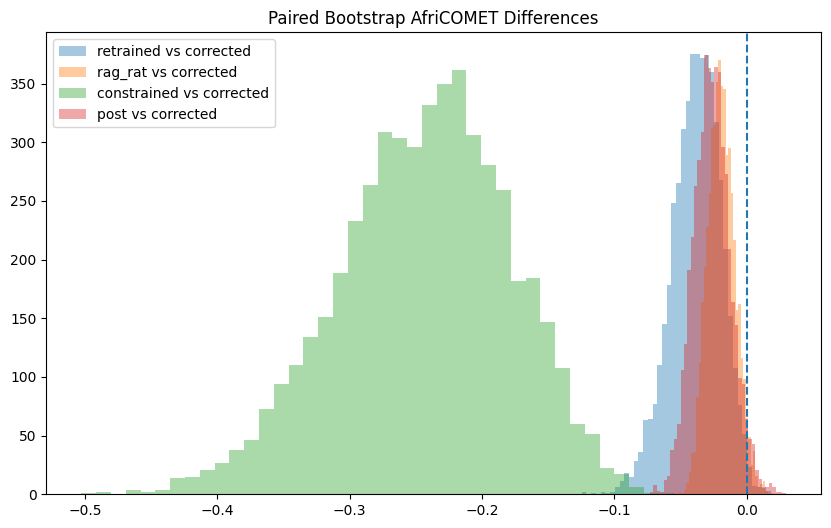

In [29]:
# plt.figure(figsize=(10,6))

# plt.hist(baseline_vs_retrained["dist"], bins=40, alpha=0.6, label="Retrained - Baseline")
# plt.hist(baseline_vs_rag["dist"], bins=40, alpha=0.6, label="RAG - Baseline")
# plt.hist(baseline_vs_post["dist"], bins=40, alpha=0.6, label="Post - Baseline")

# plt.axvline(0, linestyle="--")

# plt.title("Paired Bootstrap Distributions")
# plt.xlabel("Score Difference")
# plt.ylabel("Frequency")

# plt.legend()
# plt.show()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for k, v in results.items():
    plt.hist(v["dist"], bins=40, alpha=0.4, label=k)

plt.axvline(0, linestyle="--")
plt.legend()
plt.title("Paired Bootstrap AfriCOMET Differences")
plt.show()